# Model V01 — Frozen Formal Baseline — South Central Storage

This notebook preserves model V01, the frozen South Central full-sample formal baseline, plus an earlier Central-only EIA-930 research snapshot. V02 is documented in `06_model_v02_eia930_central_florida.ipynb`; the current selected V03 model is documented in `07_model_v03_d1_3_storage_guard.ipynb`.

In [1]:
from pathlib import Path
import json
import subprocess
import sys

import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display


def locate_project_root() -> Path:
    current = Path.cwd().resolve()
    for candidate in (current, *current.parents):
        if (candidate / 'naturalgas/evaluate_model_v02_eia930_central_florida.py').exists():
            return candidate
    raise FileNotFoundError('Run this notebook from inside henry-hub-natural-gas.')


PROJECT_ROOT = locate_project_root()
FORMAL_DIR = PROJECT_ROOT / 'results/models/v01_south_central_storage'
SELECTED_DIR = PROJECT_ROOT / 'results/models/v02_eia930_central_florida'
SELECTED_SCRIPT = PROJECT_ROOT / 'naturalgas/evaluate_model_v02_eia930_central_florida.py'
RUN_SELECTED_EVALUATOR = False

if RUN_SELECTED_EVALUATOR:
    subprocess.run([sys.executable, str(SELECTED_SCRIPT)], cwd=PROJECT_ROOT, check=True)

formal_summary = json.loads((FORMAL_DIR / 'summary.json').read_text(encoding='utf-8'))
selected_summary = json.loads((SELECTED_DIR / 'summary.json').read_text(encoding='utf-8'))
formal_daily = pd.read_parquet(FORMAL_DIR / 'strategy_daily.parquet')
selected_daily = pd.read_parquet(SELECTED_DIR / 'strategy_daily.parquet')
selected_annual = pd.read_csv(SELECTED_DIR / 'annual_metrics.csv')
formal_daily['date'] = pd.to_datetime(formal_daily['date'])
selected_daily['date'] = pd.to_datetime(selected_daily['date'])
print('Formal sample:', formal_summary['sample_start'][:10], 'to', formal_summary['sample_end'][:10])
print('Selected overlap:', selected_summary['sample_start'][:10], 'to', selected_summary['sample_end'][:10])

Formal sample: 2017-07-03 to 2026-07-13
Selected overlap: 2019-06-05 to 2026-07-13


## Historical full-sample baseline

The original South Central strategy remains the full-sample reference. All results are net of 2.5 bps per unit of position turnover.

In [2]:
def sortino_stats(net_return: pd.Series) -> tuple[float, float]:
    log_return = np.log1p(pd.to_numeric(net_return, errors='coerce').dropna())
    downside = log_return.clip(upper=0.0)
    annual_downside = float(np.sqrt(np.square(downside).mean()) * np.sqrt(252.0))
    sortino = float(log_return.mean() * 252.0 / annual_downside)
    return sortino, annual_downside


formal_metrics = formal_summary['selected_full_metrics']
formal_sortino, formal_downside = sortino_stats(formal_daily['net_return_south_central_total'])
formal_table = pd.DataFrame([{
    'Version': 'South Central historical baseline',
    'Sample': f"{formal_summary['sample_start'][:10]} to {formal_summary['sample_end'][:10]}",
    'Sharpe': formal_metrics['sharpe_zero_rf'],
    'Sortino': formal_sortino,
    'CAGR': formal_metrics['cagr'],
    'Maximum drawdown': formal_metrics['maximum_drawdown'],
    'Win rate': formal_metrics['win_rate'],
}]).set_index('Version')
display(formal_table.style.format({
    'Sharpe': '{:.3f}', 'Sortino': '{:.3f}', 'CAGR': '{:.2%}',
    'Maximum drawdown': '{:.2%}', 'Win rate': '{:.2%}',
}))

,Sample,Sharpe,Sortino,CAGR,Maximum drawdown,Win rate
Version,,,,,,
South Central historical baseline,2017-07-03 to 2026-07-13,1.673,2.834,14.61%,-6.07%,52.49%


## Selected EIA-930 enhancement

The selected version retains the GFS wind and solar factors, reallocates 10% of the top-level fundamental slot to a continuous total non-gas generation-shortfall signal, and applies the existing event veto after the score is formed.

In [3]:
base = selected_summary['baseline_metrics']
selected = selected_summary['selected_metrics']
change = selected_summary['change_vs_baseline']
selected_table = pd.DataFrame([
    {
        'Version': 'Current GFS + event veto',
        'Sharpe': base['sharpe'], 'Sortino': base['sortino'],
        'Downside deviation': base['annualized_downside_deviation'],
        'CAGR': base['cagr'], 'Maximum drawdown': base['maximum_drawdown'],
        'Total turnover': base['total_turnover'],
    },
    {
        'Version': 'Selected + 10% total non-gas shortfall',
        'Sharpe': selected['sharpe'], 'Sortino': selected['sortino'],
        'Downside deviation': selected['annualized_downside_deviation'],
        'CAGR': selected['cagr'], 'Maximum drawdown': selected['maximum_drawdown'],
        'Total turnover': selected['total_turnover'],
    },
]).set_index('Version')
display(selected_table.style.format({
    'Sharpe': '{:.3f}', 'Sortino': '{:.3f}',
    'Downside deviation': '{:.2%}', 'CAGR': '{:.2%}',
    'Maximum drawdown': '{:.2%}', 'Total turnover': '{:.2f}',
}))
display(Markdown(
    f"**Selected change:** Sharpe `{change['sharpe']:+.3f}`, "
    f"Sortino `{change['sortino']:+.3f}`, CAGR `{change['cagr']:+.2%}`, "
    f"and cumulative incremental net return "
    f"`{change['cumulative_incremental_net_return']:+.2%}`."
))

,Sharpe,Sortino,Downside deviation,CAGR,Maximum drawdown,Total turnover
Version,,,,,,
Current GFS + event veto,1.842,3.132,5.21%,17.65%,-6.07%,121.30
Selected + 10% total non-gas shortfall,1.930,3.213,5.34%,18.65%,-6.07%,127.79


**Selected change:** Sharpe `+0.088`, Sortino `+0.082`, CAGR `+1.00%`, and cumulative incremental net return `+6.05%`.

## Latest strategy dashboard

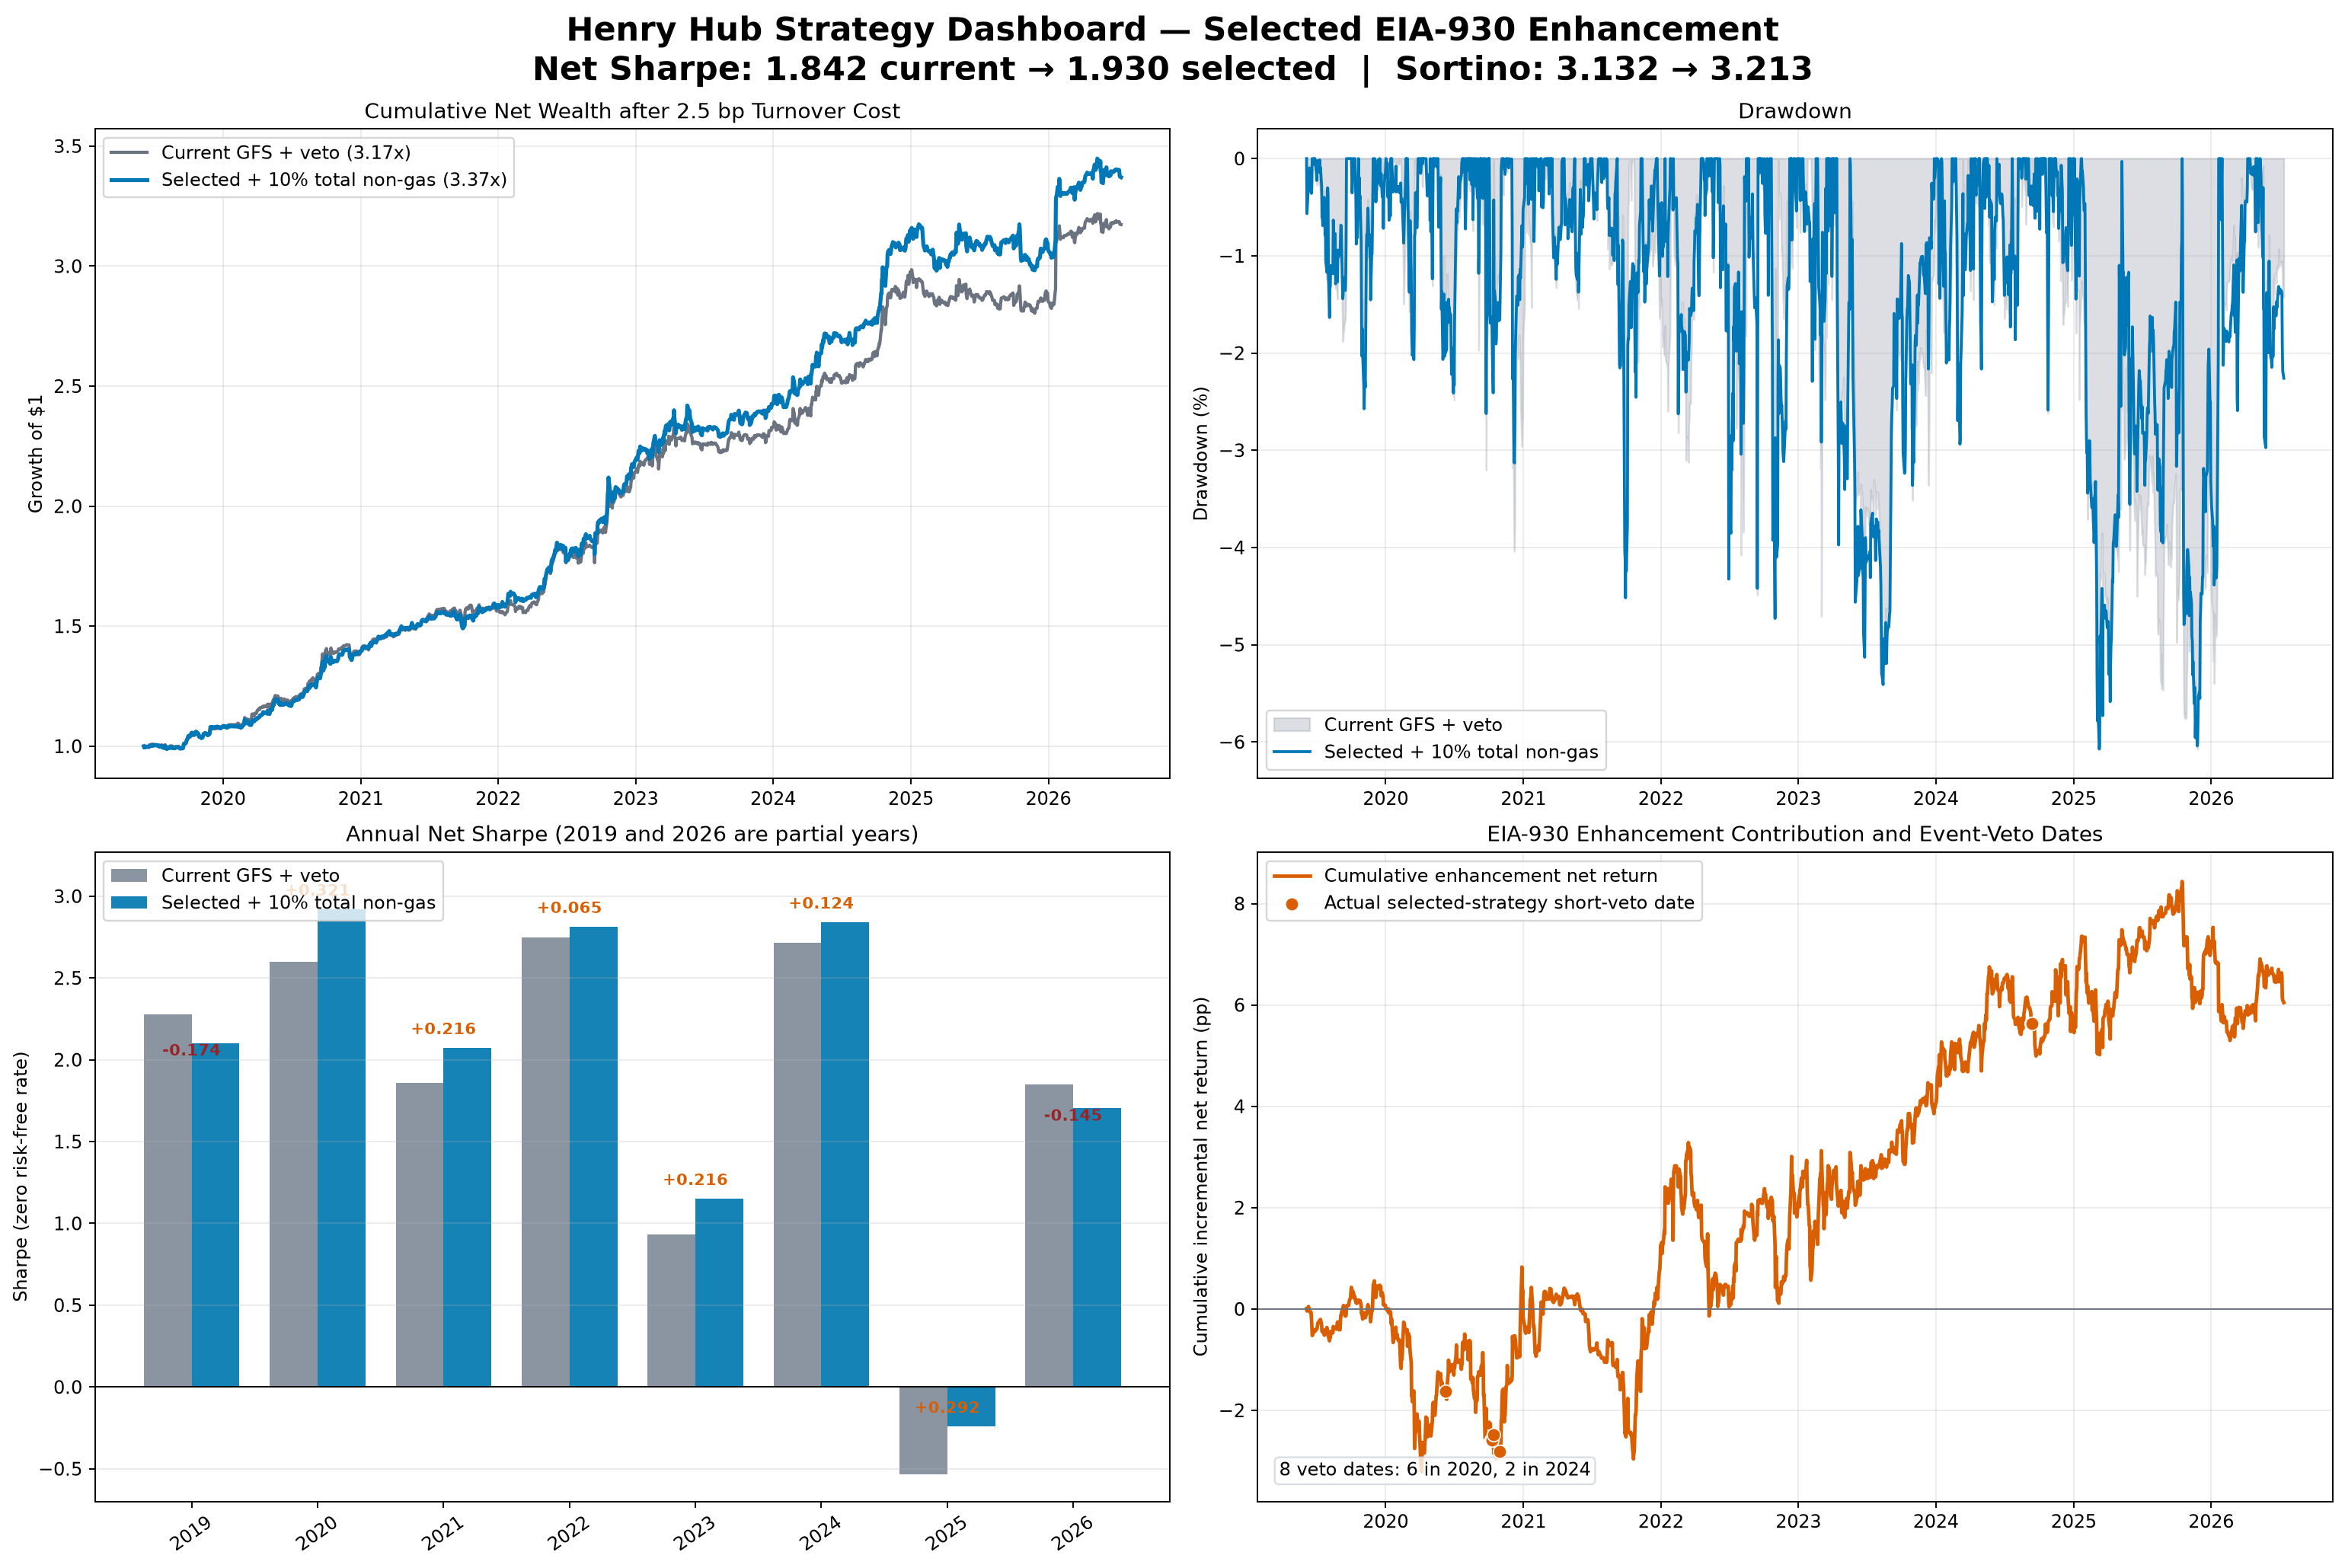

/home/syang_braeswoodcarbon_com/2026-intern-projects/henry-hub-natural-gas/results/models/v02_eia930_central_florida/dashboard.png


In [4]:
dashboard_path = SELECTED_DIR / 'dashboard.png'
display(Image(filename=str(dashboard_path)))
print(dashboard_path)

## Selected top-level allocation

In [5]:
allocation = pd.DataFrame([
    {'Signal block': 'Legacy weather block', 'Peak season': '45.0%', 'Shoulder season': '22.5%', 'Role': 'Retained'},
    {'Signal block': 'GFS wind', 'Peak season': '15.0%', 'Shoulder season': '22.5%', 'Role': 'Retained forecast factor'},
    {'Signal block': 'GFS solar', 'Peak season': '0–10.0%', 'Shoulder season': '0–10.0%', 'Role': 'Daylight-scaled'},
    {'Signal block': 'EIA-930 total non-gas shortfall', 'Peak season': '10.0%', 'Shoulder season': '10.0%', 'Role': 'Selected continuous enhancement'},
    {'Signal block': 'Nine-factor gas fundamentals', 'Peak season': '20–30.0%', 'Shoulder season': '35–45.0%', 'Role': 'Residual after solar and EIA-930 funding'},
]).set_index('Signal block')
allocation

,Peak season,Shoulder season,Role
Signal block,,,
Legacy weather block,45.0%,22.5%,Retained
GFS wind,15.0%,22.5%,Retained forecast factor
GFS solar,0–10.0%,0–10.0%,Daylight-scaled
EIA-930 total non-gas shortfall,10.0%,10.0%,Selected continuous enhancement
Nine-factor gas fundamentals,20–30.0%,35–45.0%,Residual after solar and EIA-930 funding


## Actual selected-strategy veto dates

The event controller can cancel a conflicting short but cannot create or amplify a position.

In [6]:
veto = selected_daily.loc[selected_daily['selected_veto_applied'], [
    'date', 'shutin_notice_event_names', 'shutin_notice_source_report_dates',
    'shutin_notice_revision_mmcfd',
    'position_pre_veto__eia930_total_nongas_10pct',
    'position__eia930_total_nongas_10pct',
    'roll_adjusted_return', 'incremental_net_return',
]].copy().rename(columns={
    'date': 'Return date', 'shutin_notice_event_names': 'Storm',
    'shutin_notice_source_report_dates': 'Source report date',
    'shutin_notice_revision_mmcfd': 'Shut-in worsening (MMcf/d)',
    'position_pre_veto__eia930_total_nongas_10pct': 'Position before veto',
    'position__eia930_total_nongas_10pct': 'Position after veto',
    'roll_adjusted_return': 'Futures return',
    'incremental_net_return': 'Total selected-strategy increment',
})
display(veto.style.format({
    'Return date': lambda value: pd.Timestamp(value).strftime('%Y-%m-%d'),
    'Shut-in worsening (MMcf/d)': '{:,.0f}',
    'Position before veto': '{:.3f}', 'Position after veto': '{:.3f}',
    'Futures return': '{:.2%}', 'Total selected-strategy increment': '{:.2%}',
}))

,Return date,Storm,Source report date,Shut-in worsening (MMcf/d),Position before veto,Position after veto,Futures return,Total selected-strategy increment
257,2020-06-09,Cristobal_2020,2020-06-07 00:00:00 | 2020-06-08 00:00:00,952,-0.022,0.000,-1.23%,0.02%
341,2020-10-07,Delta_2020,2020-10-06 00:00:00,233,-0.154,0.000,3.41%,0.00%
342,2020-10-08,Delta_2020,2020-10-07 00:00:00,"1,102",-0.184,0.000,0.81%,0.00%
343,2020-10-09,Delta_2020,2020-10-08 00:00:00,340,-0.135,0.000,4.34%,0.00%
345,2020-10-13,Delta_2020,2020-10-11 00:00:00,9,-0.308,0.000,-0.90%,0.00%
358,2020-10-30,Zeta_2020,2020-10-29 00:00:00,356,-0.165,0.000,1.61%,0.00%
1325,2024-09-11,Francine_2024,2024-09-10 00:00:00,494,-0.030,0.000,1.70%,-0.06%
1326,2024-09-12,Francine_2024,2024-09-11 00:00:00,413,-0.121,0.000,3.83%,0.00%


## Annual comparison

In [7]:
def annual_metric(value: str, base_label: str, selected_label: str) -> pd.DataFrame:
    return selected_annual.pivot(index='year', columns='version', values=value).rename(columns={
        'current_gfs_with_veto': base_label,
        'eia930_total_nongas_10pct': selected_label,
    })


annual_table = annual_metric('sharpe', 'Current Sharpe', 'Selected Sharpe')
annual_table = annual_table.join(annual_metric('sortino', 'Current Sortino', 'Selected Sortino'))
annual_table = annual_table.join(annual_metric('total_return', 'Current return', 'Selected return'))
annual_table['Sharpe change'] = annual_table['Selected Sharpe'] - annual_table['Current Sharpe']
annual_table['Sortino change'] = annual_table['Selected Sortino'] - annual_table['Current Sortino']
annual_table['Return change'] = annual_table['Selected return'] - annual_table['Current return']
display(annual_table[[
    'Current Sharpe', 'Selected Sharpe', 'Sharpe change',
    'Current Sortino', 'Selected Sortino', 'Sortino change',
    'Current return', 'Selected return', 'Return change',
]].style.format({
    'Current Sharpe': '{:.3f}', 'Selected Sharpe': '{:.3f}', 'Sharpe change': '{:+.3f}',
    'Current Sortino': '{:.3f}', 'Selected Sortino': '{:.3f}', 'Sortino change': '{:+.3f}',
    'Current return': '{:.2%}', 'Selected return': '{:.2%}', 'Return change': '{:+.2%}',
}))

version,Current Sharpe,Selected Sharpe,Sharpe change,Current Sortino,Selected Sortino,Sortino change,Current return,Selected return,Return change
year,,,,,,,,,
2019,2.277,2.103,-0.174,4.683,4.368,-0.315,7.91%,7.98%,+0.06%
2020,2.599,2.920,+0.321,4.605,5.337,+0.732,29.43%,29.26%,-0.17%
2021,1.857,2.073,+0.216,2.874,3.180,+0.306,12.02%,13.61%,+1.59%
2022,2.749,2.814,+0.065,4.600,4.679,+0.078,36.89%,37.94%,+1.05%
2023,0.935,1.151,+0.216,1.495,1.888,+0.393,8.56%,10.71%,+2.14%
2024,2.717,2.841,+0.124,4.935,5.318,+0.383,27.39%,29.34%,+1.95%
2025,-0.533,-0.241,+0.292,-0.689,-0.308,+0.381,-3.60%,-2.00%,+1.60%
2026,1.849,1.704,-0.145,4.477,3.497,-0.979,11.12%,9.81%,-1.31%


## Nine-factor fundamental block

In [8]:
weights = pd.read_csv(FORMAL_DIR / 'strategy_weights.csv')
display(weights[[
    'component', 'internal_fundamental_weight_pct', 'source', 'removed',
]].style.format({'internal_fundamental_weight_pct': '{:.2f}%'}))

,component,internal_fundamental_weight_pct,source,removed
0,sig_low_storage,18.18%,South Central Total level vs same-week 5-year normal,False
1,sig_storage_change,9.09%,South Central Total 1-week change vs seasonal normal,False
2,sig_storage_4w_change,9.09%,South Central Total 4-week change vs seasonal normal,False
3,sig_low_production_growth,9.09%,unchanged,False
4,sig_lng_export_growth,9.09%,unchanged,False
5,sig_consumption_growth,0.00%,unchanged,True
6,sig_net_import_supply,9.09%,unchanged,False
7,sig_production_mom,9.09%,unchanged,False
8,sig_lng_export_mom,18.18%,unchanged,False
9,sig_consumption_mom,0.00%,unchanged,True


## Current selection

The selected research configuration is the existing GFS wind/solar and South Central strategy, followed by the BSEE/Sabine pure short-veto controller, with a 10% continuous EIA-930 total non-gas generation-shortfall allocation funded from the fundamental block. The historical full-sample South Central result remains the reference for the pre-enhancement period.